In [ ]:
from skimage import data, color
from skimage.transform import resize
from skimage.restoration import denoise_tv_chambolle
from scipy.signal import convolve, correlate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import time
import pywt

In [ ]:
print(dir(data))

['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


(512, 512)


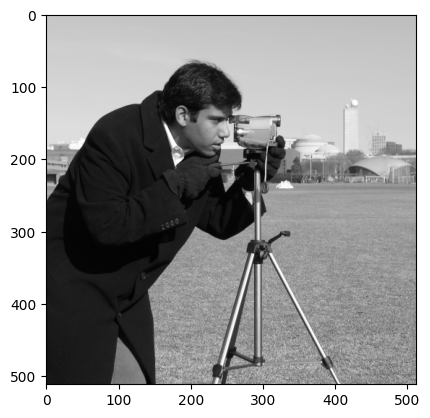

In [ ]:
image = data.camera() # Carregar imagem
#image = color.rgb2gray(image) # Mudar p/ preto e branco
n = image.shape[0] # Tamanho da imagem

# n = max(image.shape)
# image = resize(image, (n, n), anti_aliasing=True) # Imagem quadrada

print(image .shape)
plt.imshow(image , cmap='grey')

In [ ]:
n_kernel = 7 # Dimensão do kernel

# Imagem constante
kernel = np.full((n_kernel, n_kernel), 1/(n_kernel**2))

# Definir operadores
def A(x):
    return convolve(x, kernel, mode='same')

def AT(x):
    return correlate(x, kernel, mode='same')

In [ ]:
# Verificar se A é adjunta de de AT

x = 10*np.random.rand(image.shape[0], image.shape[1])
y = 10*np.random.rand(image.shape[0], image.shape[1])

print(np.sum(A(x)*y))
print(np.sum(x*AT(y)))

6512782.7756893905
6512782.775689391


In [ ]:
###########################
# Termo de regularização
###########################

# Transformada wavelet
wav = 'db5' # Wavelet escolhida
def H(x):
    coeffs = pywt.wavedec2(x, wav, mode='periodization')
    arr, slices = pywt.coeffs_to_array(coeffs)
    return arr, slices

def HT(arr, slices):
    coeffs = pywt.array_to_coeffs(arr, slices, output_format='wavedec2')
    return pywt.waverec2(coeffs, wav, mode='periodization')

# Variação total (usando diferenças centrais)
def TV(x):
    gx, gy = np.gradient(x)
    return np.sum(np.sqrt(gx**2 + gy**2))

# Calculando TV manualmente (usando diferenças progressivas)
# def TV(x):
#     """
#     Calcula o valor da Variação Total (TV) isotrópica
#     TV(x) = Σ sqrt((∇_h x)² + (∇_v x)²)
#     """
#     diff_h = np.diff(x, axis=1)
#     diff_v = np.diff(x, axis=0)

#     h, w = x.shape
#     min_h = min(diff_h.shape[1], diff_v.shape[1]) if diff_v.shape[1] > 0 else diff_h.shape[1]
#     min_v = min(diff_v.shape[0], diff_h.shape[0]) if diff_h.shape[0] > 0 else diff_v.shape[0]

#     if min_v > 0 and min_h > 0:
#         tv = np.sum(np.sqrt(diff_v[:min_v, :min_h]**2 + diff_h[:min_v, :min_h]**2))
#     else:
#         tv = 0

#     if diff_v.shape[0] > 0:
#         tv += np.sum(np.abs(diff_v[:, -1])) if diff_v.shape[1] > 0 else 0
#     if diff_h.shape[1] > 0:
#         tv += np.sum(np.abs(diff_h[-1, :])) if diff_h.shape[0] > 0 else 0

#     return tv

In [ ]:
# Verificar se H é adjunta de HT

x = 10*np.random.rand(image.shape[0], image.shape[1])
y = 10*np.random.rand(image.shape[0], image.shape[1])

Hx = H(x)
print(np.sum(Hx[0]*y))
print(np.sum(x*HT(y, Hx[1])))

# Verificar se H é ortonormal
err = np.abs(image - HT(*H(image)))
print(np.sum(err))

206076.59009410735
206076.59009410726
1.810148117509236e-08


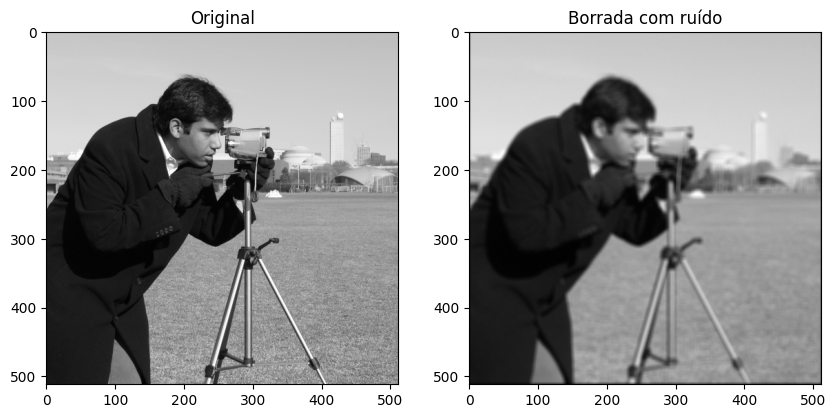

In [ ]:
# Imagem borrada e ruida
episilon = 1
b_star = A(image) # Imagem borrada
b = b_star + episilon*np.random.randn(n, n) # Ruido gaussiano

plt.figure(figsize=(10, 10))

# Imagem original
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')

# Imagem borrada e ruida
plt.subplot(1, 2, 2)
plt.imshow(b, cmap='gray')
plt.title('Borrada com ruído')

plt.show()

In [ ]:
def f(x):
    return 0.5 * np.linalg.norm(A(x) - b)**2

def grad(x):
    return AT(A(x) - b)

def exact_step(x):
    g = grad(x)
    Ag = A(g)               # A * grad
    ATAg = AT(Ag)           # A^T * (A * grad)
    num = np.sum(g * g)     # numerador
    den = np.sum(g * ATAg)  # denominador
    return num / den

# Proximal
def prox(x, alpha, reg):
    if reg is None: # por padrão será usado wavelet
        Hx = H(x)
        return HT(pywt.threshold(Hx[0], alpha), Hx[1])
    else:
        return denoise_tv_chambolle(x, weight=alpha, channel_axis=None)

# Métodos de gradiente proximal
def proximal_gradient(x0=None, step=None, prox=None, gamma=None, reg=None,
                      accelerated=False, max_iters=100, tol=None, x_star=None):

    x = np.zeros((n, n)) if x0 is None else x0

    x_values = [x]
    time_per_iter = [0]

    # Variáveis do FISTA/Nesterov
    if accelerated:
        y_prev = np.copy(x)
        t_next = 1

    for k in range(1, max_iters + 1):

        t0 = time.time()

        step = exact_step(x) if step is None else step

        # proximal
        if prox is not None:
            y = prox(x - step * grad(x), step*gamma, reg)
        else:
            y = x - step * grad(x)

        # sem aceleração -> ISTA / GD
        if not accelerated:
            x = y

        # com aceleração -> FISTA / Nesterov
        else:
            t = t_next
            t_next = 0.5 * (1 + np.sqrt(1 + 4 * t**2))

            x_new = y + ((t - 1) / t_next) * (y - y_prev)

            y_prev = y
            x = x_new

        # critério de parada
        if tol is not None and x_star is not None:

            e = np.linalg.norm(x - x_star) / np.linalg.norm(x_star)
            if e <= tol:
                method_name = ("FISTA/Nesterov"
                               if accelerated
                               else "ISTA/Gradiente" )

                print(f"{method_name} parou na iteração {k}")

                x_values.append(x)
                break

        t1 = time.time()

        x_values.append(x)
        time_per_iter.append(t1 - t0)

    return x_values, time_per_iter

# Método dos Gradientes Conjugados
def conjugate_grad(x0=None, max_iters=100, tol=None, x_star=None):
    x = np.zeros((n, n)) if x0 is None else x0 # chute inicial
    r = AT(b - A(x))
    p = np.copy(r)
    rsold = np.sum(r * r)
    x_values = [x]
    time_per_iter = [0]

    for k in range(1, max_iters+1):

        t0 = time.time()
        Ap = AT(A(p))
        step = rsold / np.sum(p * Ap)
        x = x + step * p

        # Critério de parada
        if tol is not None and x_star is not None:
            e = np.linalg.norm(x - x_star) / np.linalg.norm(x_star)
            if e <= tol:
                print(f"GC parou na iteração {k}")
                x_values.append(x)
                break

        r = r - step * Ap
        rsnew = np.sum(r * r)
        if np.sqrt(rsnew) < 1e-8:
            break
        p = r + (rsnew / rsold) * p
        rsold = rsnew

        t1 = time.time()
        x_values.append(x)
        time_per_iter.append(t1 - t0)

    return x_values, time_per_iter

In [ ]:
#----------------------
# Executar métodos
#----------------------

# Parametros
gamma = 0.1
iters = 100
tol = None # Tolerancia para avaliar o tempo de convergência

# Parcela de regularização
# reg = None # wavelet
reg = 'tv' # TV

methods = {
    "Gradiente": {
        "prox": None,
        "accelerated": False
    },

    "Nesterov": {
        "prox": None,
        "accelerated": True
    },

    "ISTA": {
        "prox": prox,
        "accelerated": False
    },

    "FISTA": {
        "prox": prox,
        "accelerated": True
    }
}

steps = {
    "fixo: 0.1": 0.1,
    "fixo: 0.5": 0.5,
    "fixo: 1.0": 1.0,
    "exato": None
}

results = {}

for method_name, params in methods.items():

    for step_name, step_value in steps.items():

        print(f"Executando {method_name} com passo {step_name}")

        x_values, time_iter = proximal_gradient(
            step=step_value,
            prox=params["prox"],
            gamma=gamma,
            reg=reg,
            accelerated=params["accelerated"],
            max_iters=iters,
            # tol=tol,
            # x_star=image
        )

        if reg is None:
            f_values = [f(x) + gamma * np.sum(np.abs(H(x)[0])) for x in x_values]
        else:
            f_values = [f(x) + gamma * TV(x) for x in x_values]


        reconstruction = x_values[np.argmin(f_values)]

        results[(method_name, step_name)] = {
            "x_values": x_values,
            "time": time_iter,
            "reconstruction": reconstruction,
            "f_values": f_values
        }

# Gradientes conjugados
x_values_cg, time_iter_cg = conjugate_grad(max_iters=iters, tol=tol, x_star=image)
if reg is None:
    f_values_cg = [f(x) + gamma*np.sum(np.abs(H(x)[0])) for x in x_values_cg]
else:
    f_values_cg = [f(x) + gamma*TV(x) for x in x_values_cg]
reconstruction_cg = x_values_cg[np.argmin(f_values_cg)]

Executando Gradiente com passo fixo: 0.1
Executando Gradiente com passo fixo: 0.5
Executando Gradiente com passo fixo: 1.0
Executando Gradiente com passo exato
Executando Nesterov com passo fixo: 0.1
Executando Nesterov com passo fixo: 0.5
Executando Nesterov com passo fixo: 1.0
Executando Nesterov com passo exato
Executando ISTA com passo fixo: 0.1
Executando ISTA com passo fixo: 0.5
Executando ISTA com passo fixo: 1.0
Executando ISTA com passo exato
Executando FISTA com passo fixo: 0.1
Executando FISTA com passo fixo: 0.5
Executando FISTA com passo fixo: 1.0
Executando FISTA com passo exato


In [ ]:
valores_min = []
m = 10000000
for key, data in results.items():
    method, step = key
    print(f"Método: {method}, passo: {step}")
    #valores_min.append(min(data['f_values']))
    if min(data['f_values']) < m:
        m = min(data['f_values'])
        method_min = method
        step_min = step
    print(f"Valor minimimo: {min(data['f_values'])}", end="\n\n")

print(f"Min grad conj: {min(f_values_cg)}", end="\n\n")
print(f"Método: {method_min}, passo: {step_min}")
print(f"Valor mínimimo dentre todos os métodos: {m}")

Método: Gradiente, passo: fixo: 0.1
Valor minimimo: 536404.9978292814

Método: Gradiente, passo: fixo: 0.5
Valor minimimo: 295404.0863079632

Método: Gradiente, passo: fixo: 1.0
Valor minimimo: 287982.39599415206

Método: Gradiente, passo: exato
Valor minimimo: 287982.41028970375

Método: Nesterov, passo: fixo: 0.1
Valor minimimo: 297716.2087362458

Método: Nesterov, passo: fixo: 0.5
Valor minimimo: 295079.2136008884

Método: Nesterov, passo: fixo: 1.0
Valor minimimo: 293986.78682870325

Método: Nesterov, passo: exato
Valor minimimo: 293962.22181777185

Método: ISTA, passo: fixo: 0.1
Valor minimimo: 541952.4629827577

Método: ISTA, passo: fixo: 0.5
Valor minimimo: 286242.1142283845

Método: ISTA, passo: fixo: 1.0
Valor minimimo: 261146.58587814297

Método: ISTA, passo: exato
Valor minimimo: 260917.3282699803

Método: FISTA, passo: fixo: 0.1
Valor minimimo: 254156.2207110192

Método: FISTA, passo: fixo: 0.5
Valor minimimo: 247422.16657536707

Método: FISTA, passo: fixo: 1.0
Valor minimi

# Análise do ganho de velocidade de convergência

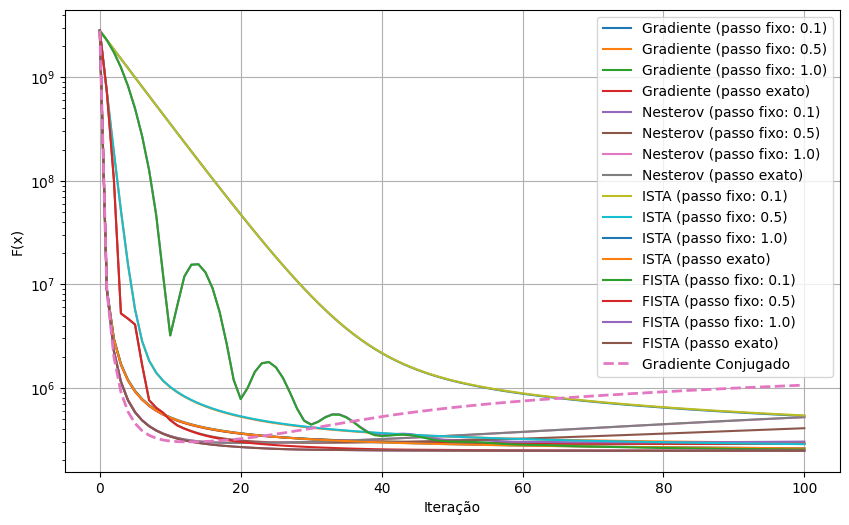

In [ ]:
plt.figure(figsize=(10, 6))

# curvas dos métodos
for key, data in results.items():
    method, step = key
    plt.plot(data["f_values"], label=f"{method} (passo {step})")

# curva do gradiente conjugado (referência)
plt.plot(f_values_cg, linestyle="--", linewidth=2, label="Gradiente Conjugado")

plt.yscale("log")
plt.xlabel("Iteração")
plt.ylabel("F(x)")
plt.legend()
plt.grid(True)

plt.show()

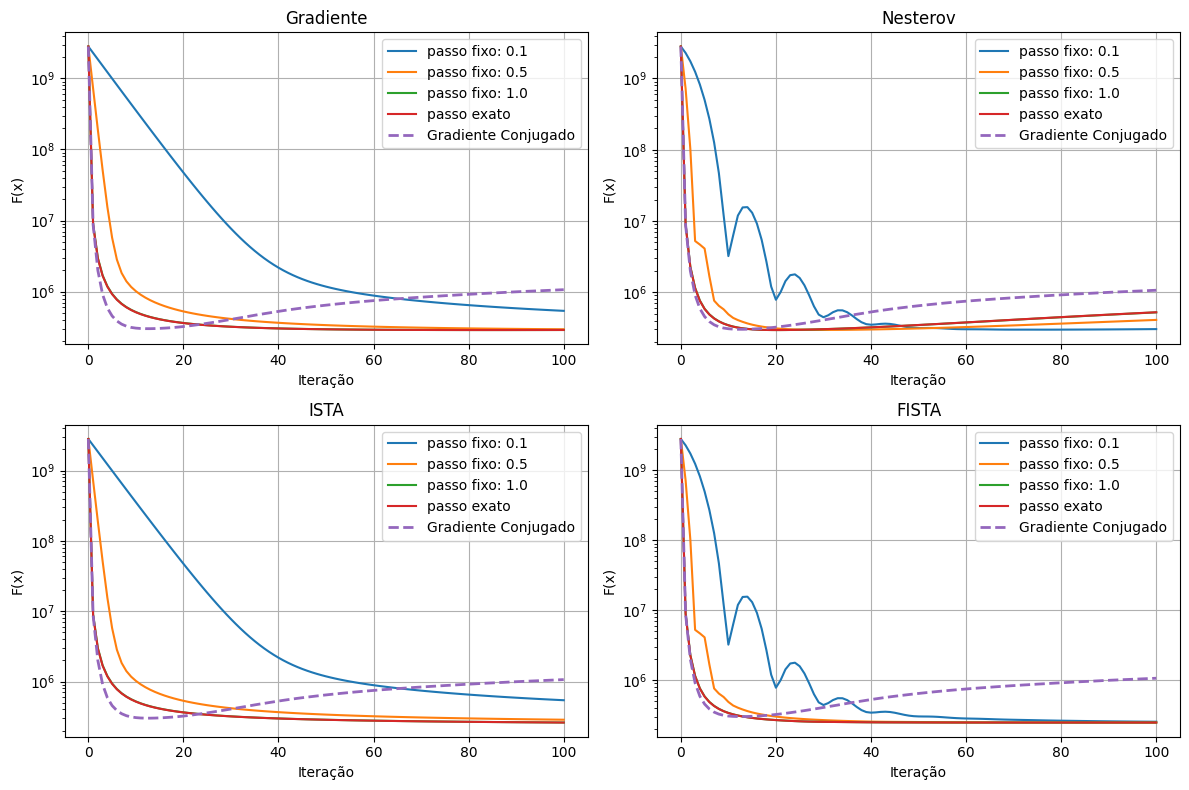

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

method_list = list(methods.keys())
step_list = list(steps.keys())

for idx, method_name in enumerate(method_list):

    ax = axes[idx // 2, idx % 2]   # posiciona no grid 2x2

    for step_name in step_list:

        key = (method_name, step_name)

        if key in results:
            data = results[key]
            ax.plot(data["f_values"], label=f"passo {step_name}")

    # curva do gradiente conjugado (referência)
    ax.plot(f_values_cg, linestyle="--", linewidth=2, label="Gradiente Conjugado")

    ax.set_title(method_name)
    ax.set_yscale("log")
    ax.set_xlabel("Iteração")
    ax.set_ylabel("F(x)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

## Analise do erro relativo

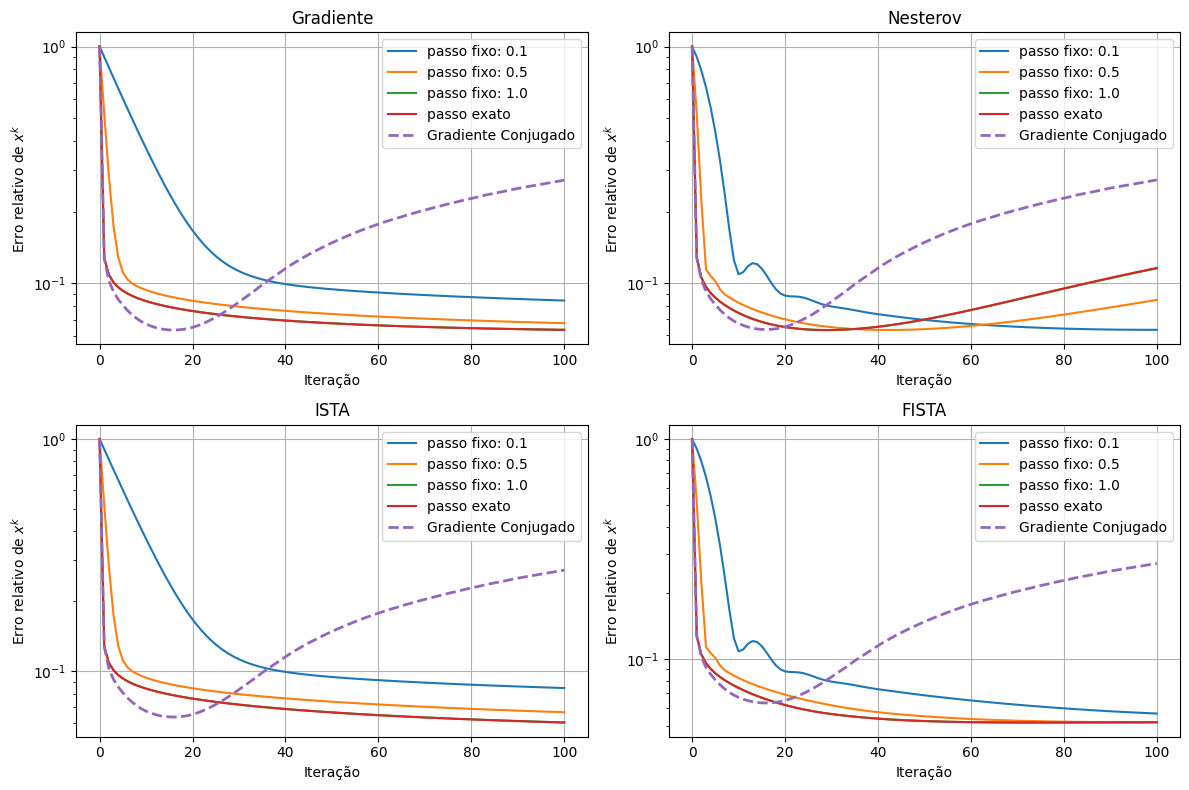

In [ ]:
#--------------------------
# Analise erros relativos
#--------------------------

erro_x = {}
erro_f = {}

for key, data in results.items():

    method, step = key

    x_values = data["x_values"]
    f_values = data["f_values"]

    # erro relativo de x
    erro_x[key] = [
        np.linalg.norm(x - image) / np.linalg.norm(image)
        for x in x_values
    ]

erro_img_cg = [np.linalg.norm(x - image) / np.linalg.norm(image) for x in x_values_cg]

# ----------------------------
# Plot dos graficos de erro
# ----------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

method_list = list(methods.keys())
step_list = list(steps.keys())

for idx, method_name in enumerate(method_list):

    ax = axes[idx // 2, idx % 2]

    for step_name in step_list:

        key = (method_name, step_name)

        if key in erro_x:
            err = erro_x[key]
            ax.plot(err, label=f"passo {step_name}")

    # curva do gradiente conjugado (referência)
    ax.plot(erro_img_cg , linestyle="--", linewidth=2, label="Gradiente Conjugado")

    ax.set_title(method_name)
    ax.set_xlabel("Iteração")
    ax.set_ylabel(r"Erro relativo de $x^k$")
    ax.set_yscale("log")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# Análise custo/benefício em tempo de computação

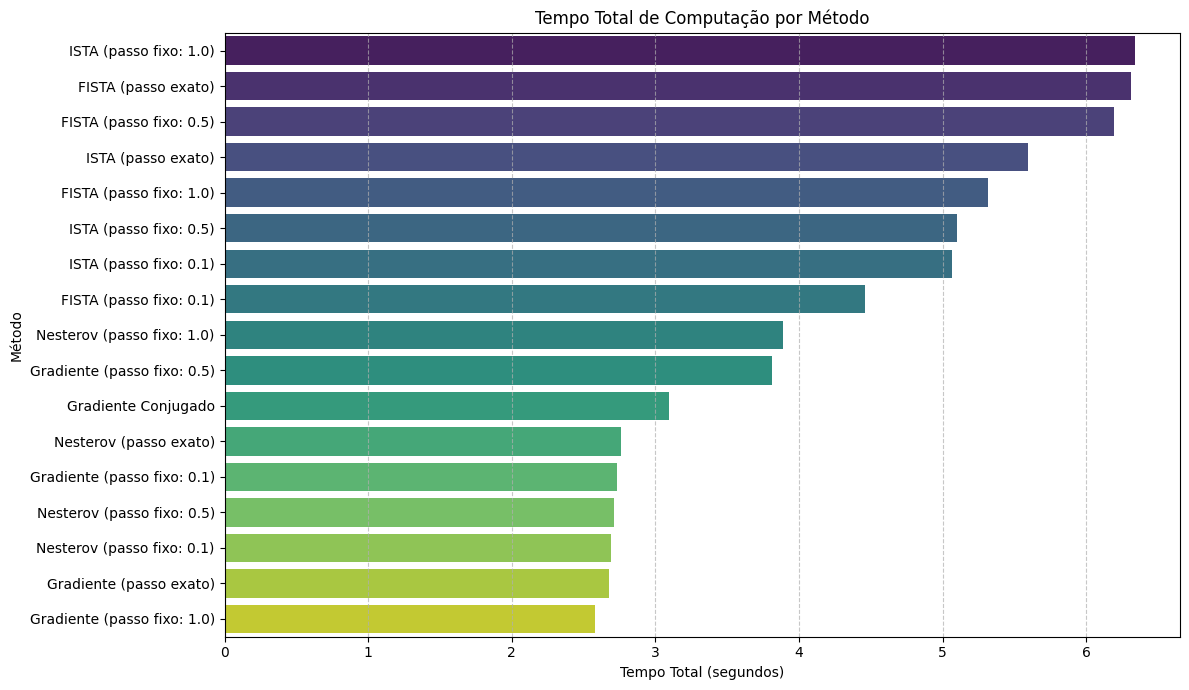

/tmp/ipykernel_715/3200796169.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0.1", "0.5", "1.0", "Exato", "CG"], rotation=45, ha='right')
/tmp/ipykernel_715/3200796169.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0.1", "0.5", "1.0", "Exato", "CG"], rotation=45, ha='right')
/tmp/ipykernel_715/3200796169.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0.1", "0.5", "1.0", "Exato", "CG"], rotation=45, ha='right')
/tmp/ipykernel_715/3200796169.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0.1", "0.5", "1.0", "Exato", "CG"], rotation=45, ha='right')


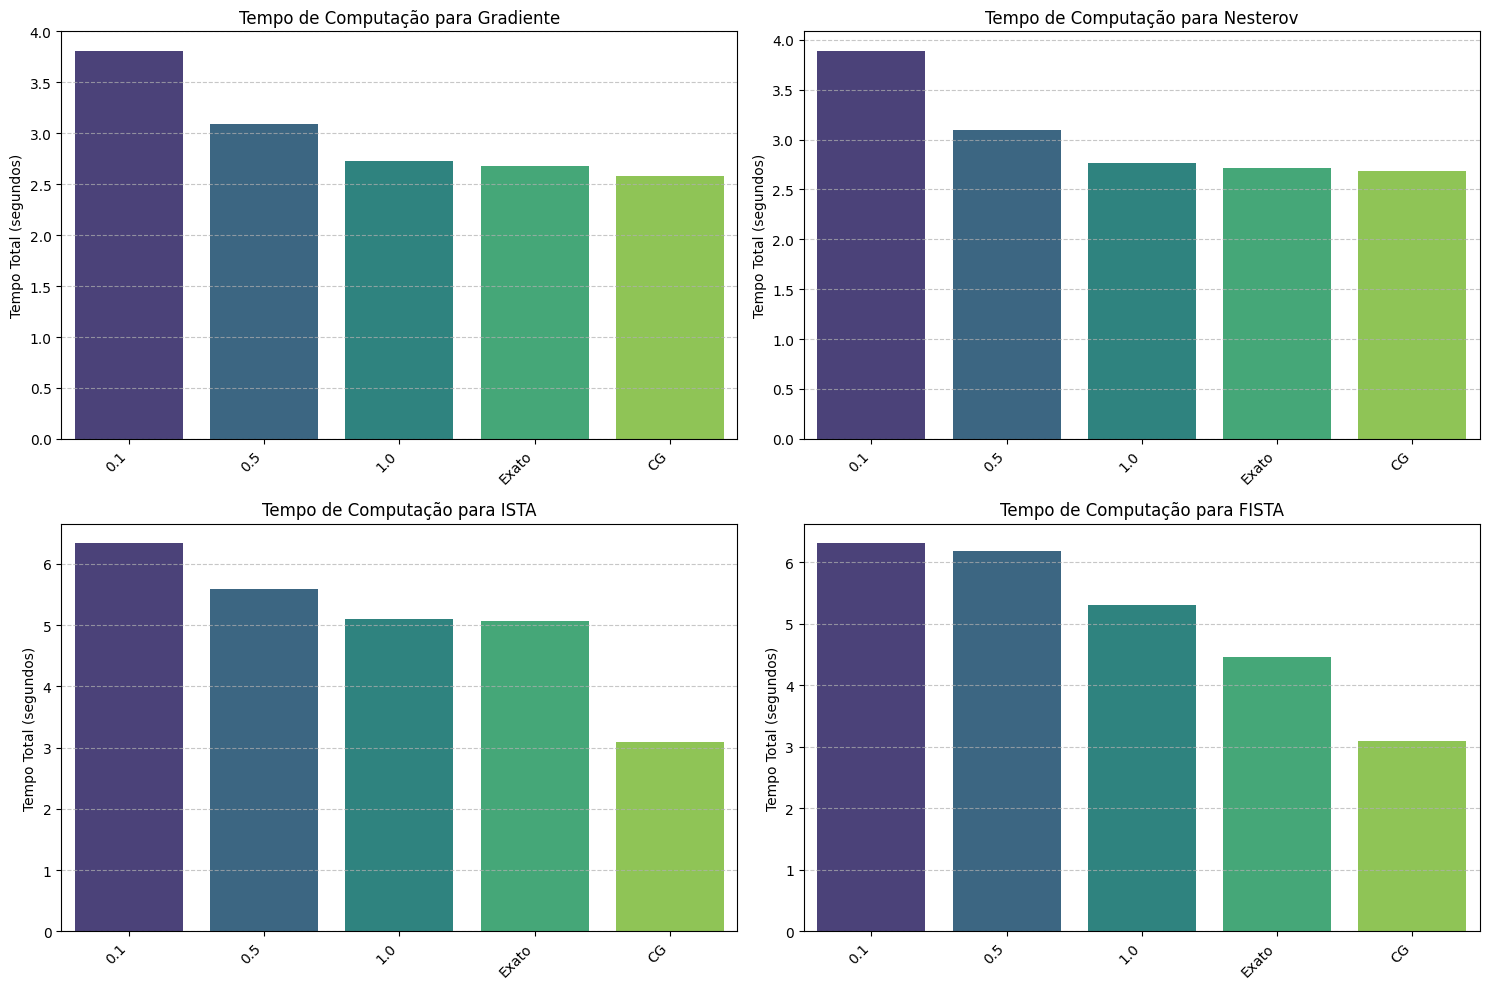

In [ ]:
# Preparar dados para o gráfico de barras e tabela
plot_data = []
table_data = []

# Adicionar dados dos métodos de 'results'
for key, data in results.items():
    method_name, step_name = key
    full_method_name = f"{method_name} (passo {step_name})"
    total_time = sum(data["time"])
    num_iterations = len(data["x_values"]) - 1 # len(x_values) includes x0
    time_per_iteration = total_time / num_iterations if num_iterations > 0 else 0

    plot_data.append({"Método": full_method_name, "Tempo Total (s)": total_time})
    table_data.append({
        "Método": full_method_name,
        "Tempo por Iteração (s)": time_per_iteration,
        "Número de Iterações": num_iterations,
        "Tempo Total (s)": total_time
    })

# Adicionar dados do Gradiente Conjugado
total_time_cg = sum(time_iter_cg)
num_iterations_cg = len(x_values_cg) - 1 # len(x_values_cg) inclui x0
time_per_iteration_cg = total_time_cg / num_iterations_cg if num_iterations_cg > 0 else 0

plot_data.append({"Método": "Gradiente Conjugado", "Tempo Total (s)": total_time_cg})
table_data.append({
    "Método": "Gradiente Conjugado",
    "Tempo por Iteração (s)": time_per_iteration_cg,
    "Número de Iterações": num_iterations_cg,
    "Tempo Total (s)": total_time_cg
})

df_plot = pd.DataFrame(plot_data)
df_table = pd.DataFrame(table_data)

df_cg = df_table[df_table['Método'] == 'Gradiente Conjugado'].round(4).reset_index(drop=True)

method_names_display = {
    "Gradiente": "Gradiente",
    "Nesterov": "Nesterov",
    "ISTA": "ISTA",
    "FISTA": "FISTA"
}

# Gráfico de Barras
plt.figure(figsize=(12, 7))
sns.barplot(x="Tempo Total (s)", y="Método", data=df_plot.sort_values(by="Tempo Total (s)", ascending=False), palette="viridis", hue="Método", legend=False)
plt.title("Tempo Total de Computação por Método")
plt.xlabel("Tempo Total (segundos)")
plt.ylabel("Método")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, (method_key, display_name) in enumerate(method_names_display.items()):
    ax = axes[idx]

    # Filtrar os dados para o método atual, incluindo todas as variações de passo
    df_method = df_table[df_table['Método'].str.startswith(method_key)].copy()

    # Concatenar com os dados do Gradiente Conjugado
    df_combined = pd.concat([df_method, df_cg])

    # Plotar o gráfico de barras
    sns.barplot(x="Método", y="Tempo Total (s)", data=df_combined.sort_values(by="Tempo Total (s)", ascending=False), palette="viridis", hue="Método", legend=False, ax=ax)
    ax.set_title(f"Tempo de Computação para {display_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Tempo Total (segundos)")
    ax.set_xticklabels(["0.1", "0.5", "1.0", "Exato", "CG"], rotation=45, ha='right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Tabela e Salvamento em Excel
#display(df_table.round(4)) # Exibir a tabela com 4 casas decimais
# directory = '/content/gdrive/MyDrive/PUB/Otimização Não Linear'
# excel_filename = "tempos_metodos_otimizacao.xlsx"
# df_table.to_excel(f"{directory}/{excel_filename}", index=False)
# print(f"Tabela de tempos salva em '{excel_filename}'")

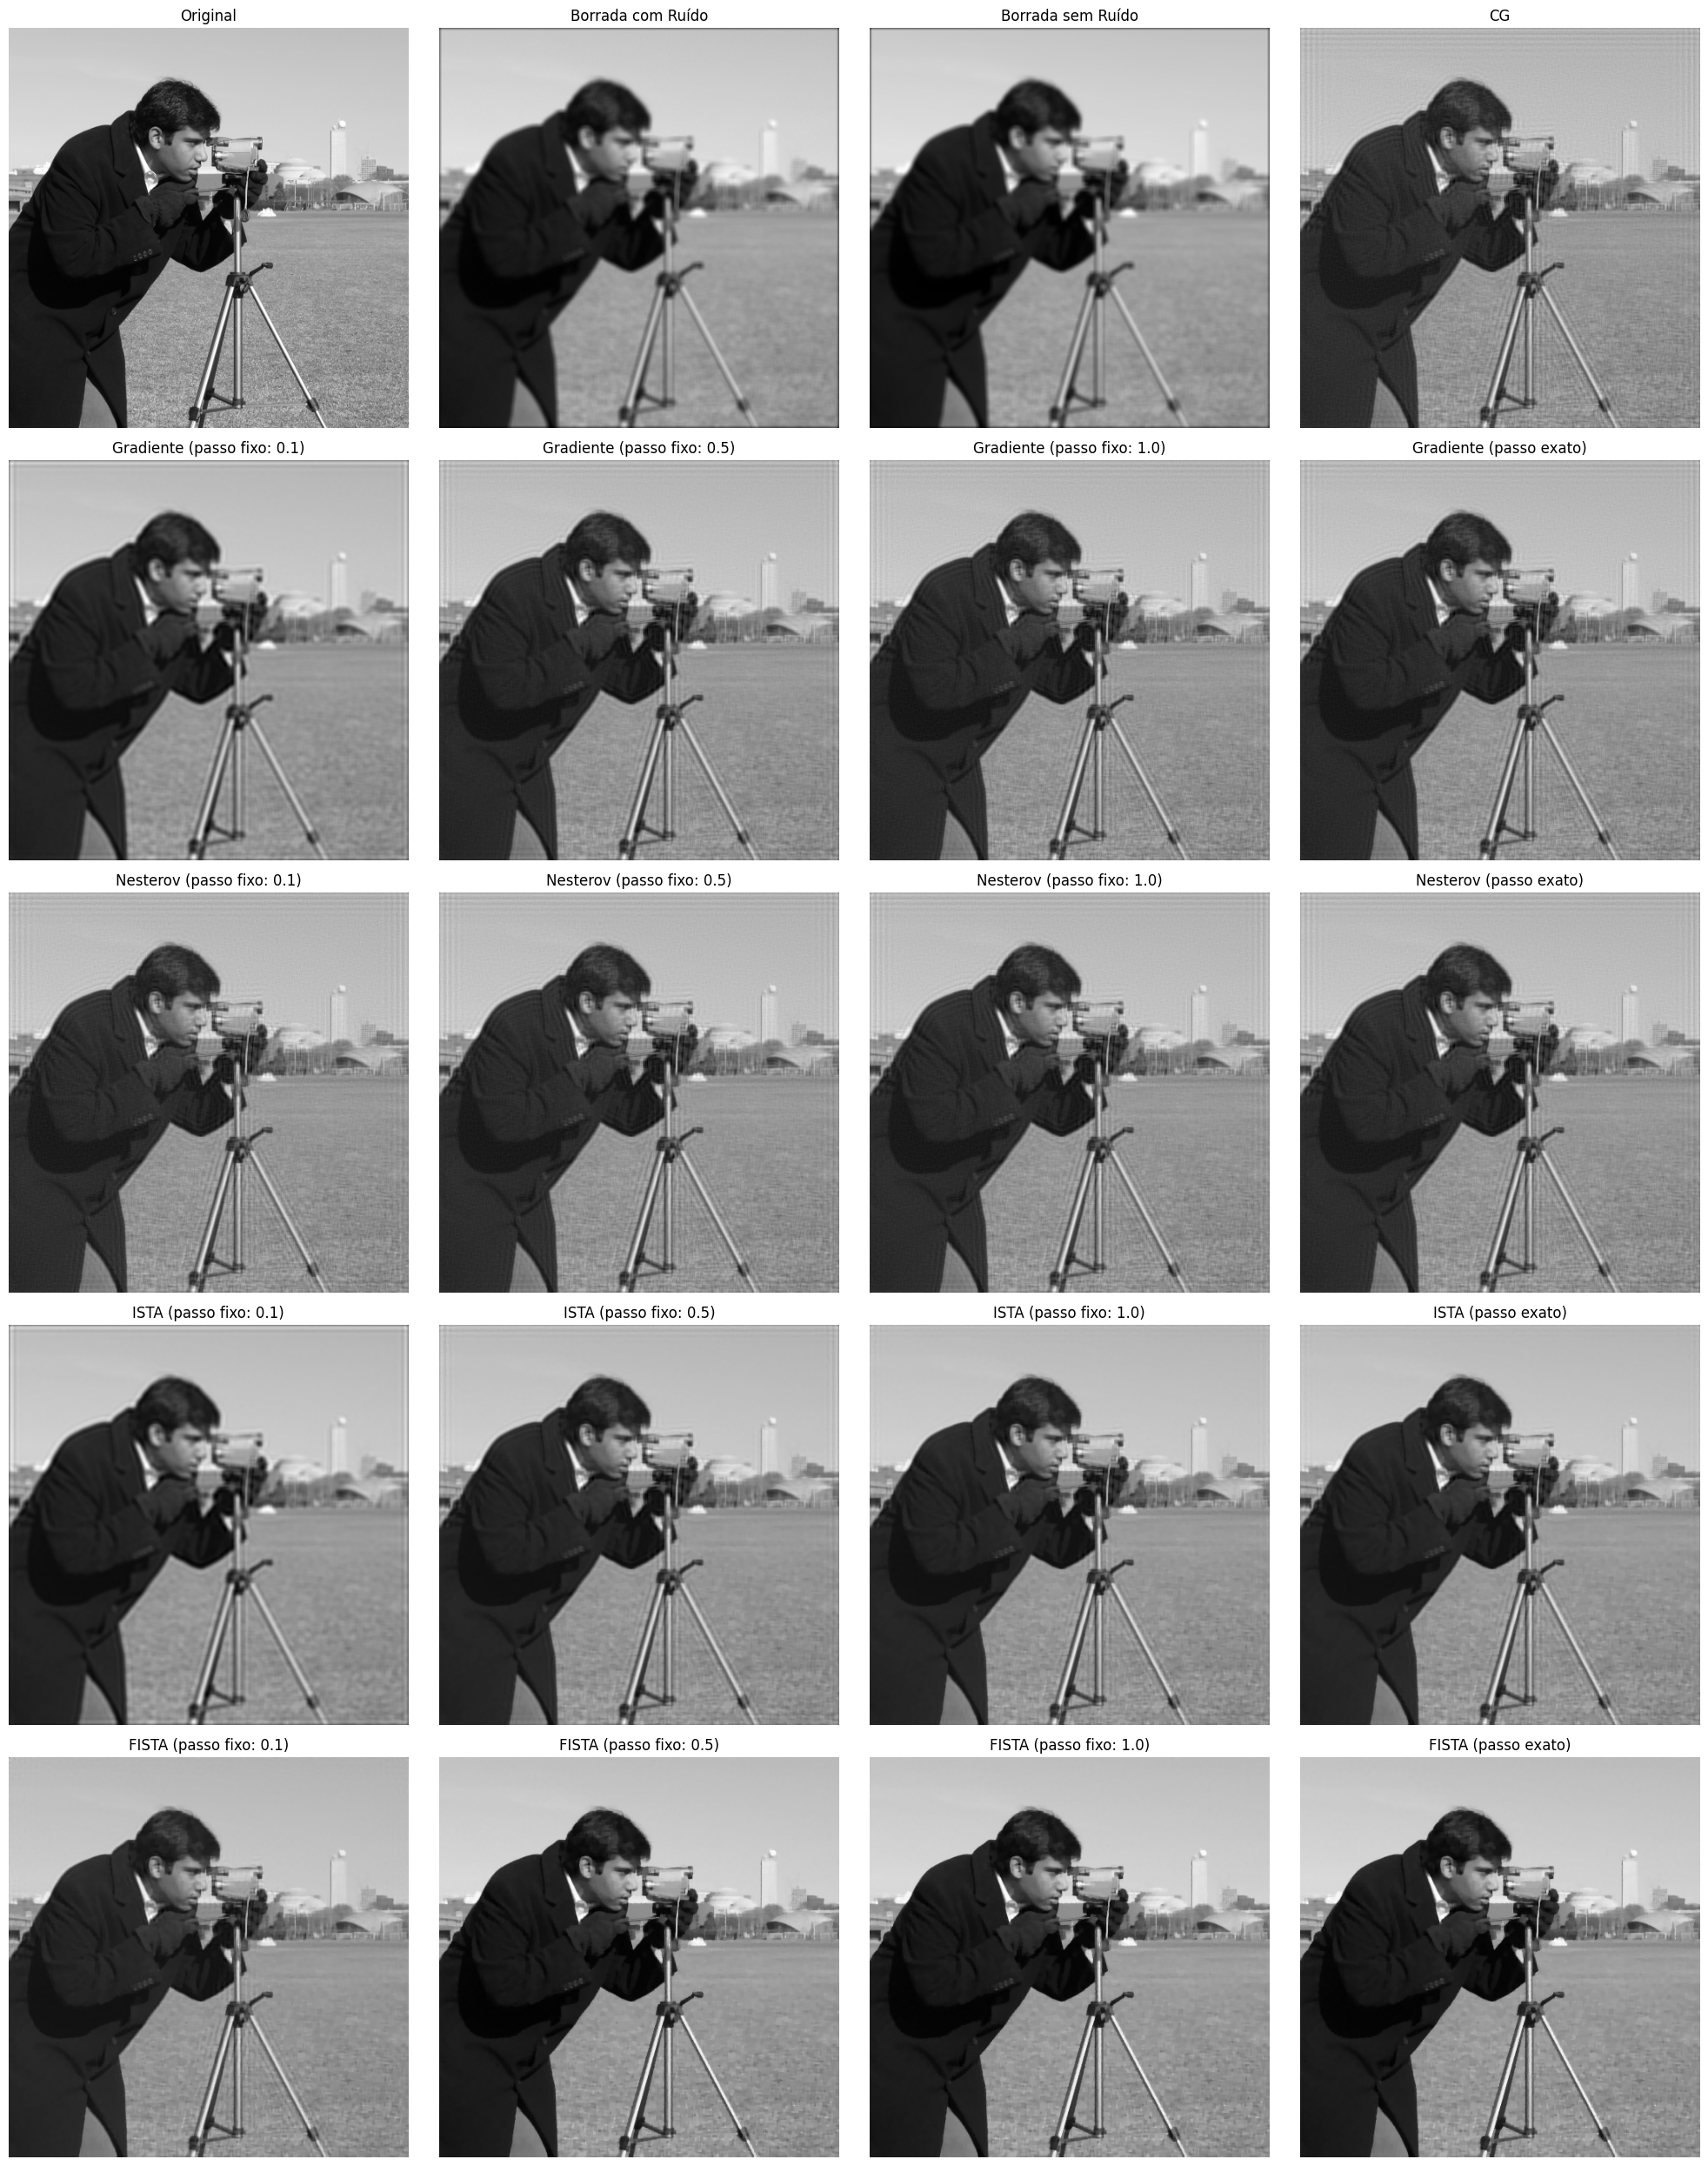

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(20, 25))
axes = axes.flatten()

plot_idx = 0

# Imagem original
axes[plot_idx].imshow(image, cmap='gray')
axes[plot_idx].set_title("Original")
axes[plot_idx].axis('off')
plot_idx += 1

axes[plot_idx].imshow(b, cmap='gray')
axes[plot_idx].set_title("Borrada com Ruído")
axes[plot_idx].axis('off')
plot_idx += 1

axes[plot_idx].imshow(b_star, cmap='gray')
axes[plot_idx].set_title("Borrada sem Ruído")
axes[plot_idx].axis('off')
plot_idx += 1

# Plot Gradiente Conj
axes[plot_idx].imshow(reconstruction_cg, cmap='gray')
axes[plot_idx].set_title("CG")
axes[plot_idx].axis('off')
plot_idx += 1

method_order = ["Gradiente", "Nesterov", "ISTA", "FISTA"]
step_order = ["fixo: 0.1", "fixo: 0.5", "fixo: 1.0", "exato"]

# Plot reconstrucao
for method_name in method_order:
    for step_name in step_order:
        key = (method_name, step_name)
        if key in results:
            reconstruction = results[key]["reconstruction"]
            axes[plot_idx].imshow(reconstruction, cmap='gray')
            axes[plot_idx].set_title(f"{method_name} (passo {step_name})")
            axes[plot_idx].axis('off')
            plot_idx += 1

plt.tight_layout()
plt.show()